# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] numpy==1.25.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 49.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [76]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [77]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [78]:
# mount the drive to import the data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
# Load the image file of the dataset
images = np.load('/content/drive/My Drive/Colab Notebooks/computer vision and CNN/project/images_proj.npy')

# Load the labels file of the dataset
labels = pd.read_csv('/content/drive/My Drive/Colab Notebooks/computer vision and CNN/project/Labels_proj.csv')

# Data Overview


In [80]:
#Let's print the shape of the images and labels
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


There are 631 RGB  images of shape 200 x 200 X 3, each image having 3 channels.

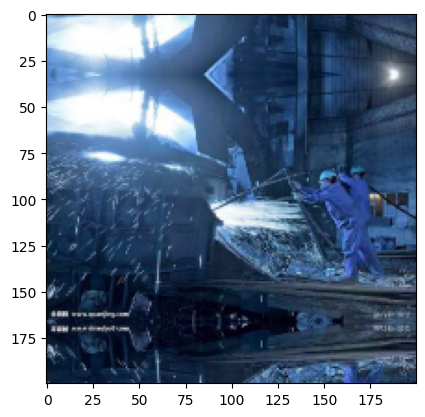

In [81]:
plt.imshow(images[5])

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

In [82]:
def plot_images(images,labels):
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

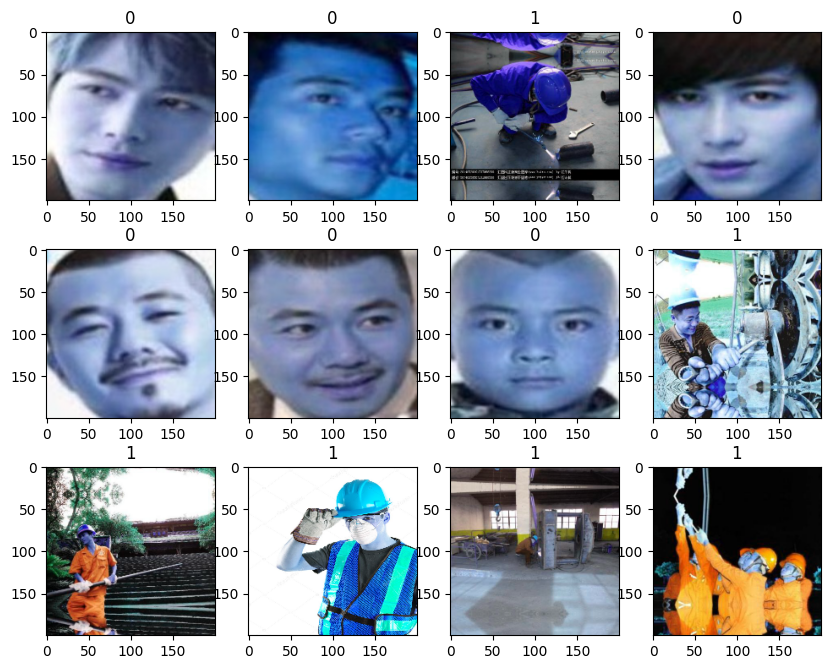

In [83]:
plot_images(images,labels)

## Checking for class imbalance


In [84]:
labels['Label'].unique()

array([1, 0])

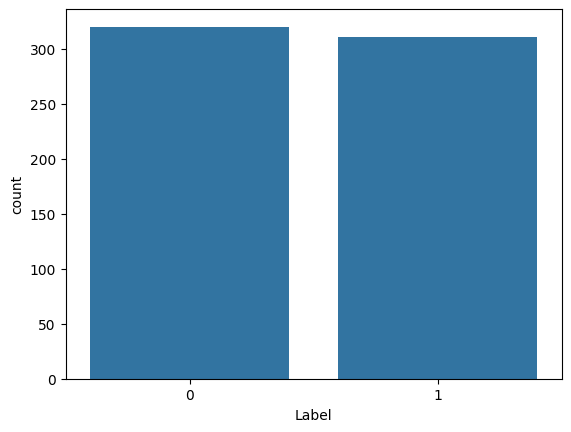

In [85]:
sns.countplot(x='Label', data = labels)
plt.show();

- As We can see from the above plot, the dataset is quite balanced.
- There are 311 images showing workers wearing helmets.
- There are 320 images showing workers not wearing helmets.

# **Data Preprocessing**

## Converting images to grayscale

In [86]:
grayscale_images = []
for img in images:
    grayscale_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
#images = np.array(grayscale_images)

In [87]:
from google.colab.patches import cv2_imshow

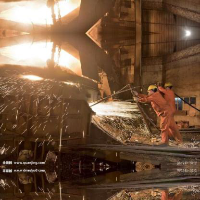

In [88]:
cv2_imshow(images[5])

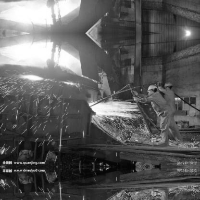

In [89]:
cv2_imshow(grayscale_images[5])

### Splitting the dataset



- As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
- We are using the `train_test_split()` function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.

In [90]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(np.array(grayscale_images),labels , test_size=0.2, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [91]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(504, 200, 200) (504, 1)
(63, 200, 200) (63, 1)
(64, 200, 200) (64, 1)


As we already know, the images are in grayscale, so let us **reshape the arrays to just have a single channel**.

In [92]:
# Reshape dataset to have a single channel
X_train = X_train.reshape((X_train.shape[0], 200, 200, 1))
X_val = X_val.reshape((X_val.shape[0], 200, 200, 1))
X_test = X_test.reshape((X_test.shape[0], 200, 200, 1))

In [93]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(504, 200, 200, 1) (504, 1)
(63, 200, 200, 1) (63, 1)
(64, 200, 200, 1) (64, 1)


- In case of Normal CNN model,
  - The size of training image data is (504, 200, 200, 1).
  - The size of training image data is (63, 200, 200, 1).
  - The size of training image data is (64, 200, 200, 1).

As we are going to use VGG model later, so for that we need the images with 3 channels, so splitiing the original image data into train, validation and test data.

In [94]:
X_train_vgg, X_temp_vgg, y_train_vgg, y_temp_vgg = train_test_split(np.array(images),labels , test_size=0.2, random_state=42,stratify=labels)
X_val_vgg, X_test_vgg, y_val_vgg, y_test_vgg = train_test_split(X_temp_vgg, y_temp_vgg , test_size=0.5, random_state=42,stratify=y_temp_vgg)

In [95]:
print(X_train_vgg.shape,y_train_vgg.shape)
print(X_val_vgg.shape,y_val_vgg.shape)
print(X_test_vgg.shape,y_test_vgg.shape)

(504, 200, 200, 3) (504, 1)
(63, 200, 200, 3) (63, 1)
(64, 200, 200, 3) (64, 1)


- In case of transfer learning models or VGG model,
  - The size of training image data is (504, 200, 200, 3).
  - The size of training image data is (63, 200, 200, 3).
  - The size of training image data is (64, 200, 200, 3).

In [96]:
print(y_train_vgg.value_counts())
print(y_val_vgg.value_counts())
print(y_test_vgg.value_counts())

Label
0        256
1        248
Name: count, dtype: int64
Label
0        32
1        31
Name: count, dtype: int64
Label
0        32
1        32
Name: count, dtype: int64


### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [97]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

In [98]:
# Normalizing the image pixels
X_train_vgg_normalized = X_train_vgg.astype('float32')/255.0
X_val_vgg_normalized = X_val_vgg.astype('float32')/255.0
X_test_vgg_normalized = X_test_vgg.astype('float32')/255.0

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [99]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [100]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Simple Convolutional Neural Network (CNN)

In [101]:
model_1 = Sequential()
model_1.add(Conv2D(64, (3,3), activation='relu', input_shape=(200, 200, 1), padding = 'same'))
model_1.add(MaxPooling2D(2,2))
model_1.add(BatchNormalization())
model_1.add(Conv2D(32, (3,3), activation='relu', padding = 'same'))
model_1.add(MaxPooling2D(2,2))
model_1.add(BatchNormalization())
model_1.add(Conv2D(32, (3,3), activation='relu', padding = 'same'))
model_1.add(MaxPooling2D(2,2))
model_1.add(Conv2D(16, (3,3), activation='relu', padding = 'same'))
model_1.add(Flatten())
model_1.add(Dense(64, activation='relu'))
model_1.add(Dense(32, activation='relu'))
model_1.add(Dense(32, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))

In [102]:
model_1.compile(loss="binary_crossentropy", optimizer="adam", metrics = ['accuracy'])
model_1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 200, 200, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,593 (2.58 MB)

 Trainable params: 676,401 (2.58 MB)

 Non-trainable params: 192 (768.00 B)

In [103]:
train_datagen_1 = ImageDataGenerator()

In [104]:
# Epochs
epochs = 20
# Batch size
batch_size = 32

history_model_1 = model_1.fit(train_datagen_1.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 336ms/step - accuracy: 0.8771 - loss: 0.2475 - val_accuracy: 0.7619 - val_loss: 0.6284
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8889 - val_loss: 0.5821
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9915 - loss: 0.0528 - val_accuracy: 0.5079 - val_loss: 0.6751
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.5079 - val_loss: 0.6876
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9915 - loss: 0.0169 - val_accuracy: 0.5079 - val_loss: 0.6447
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.5873 - val_loss: 0.6272
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9958 - loss: 0.0106 - val_accuracy: 0.5079 - val_loss: 0.8959
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.4260e-04 - val_accuracy: 0.5079 -

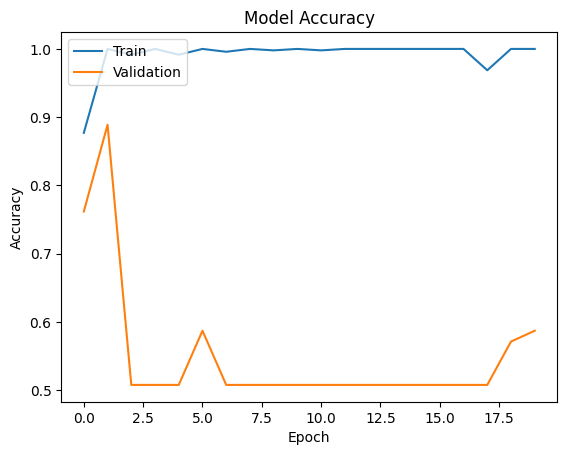

In [105]:
plt.plot(history_model_1.history['accuracy'])
plt.plot(history_model_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [106]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.615079  0.615079   0.781023  0.544332


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


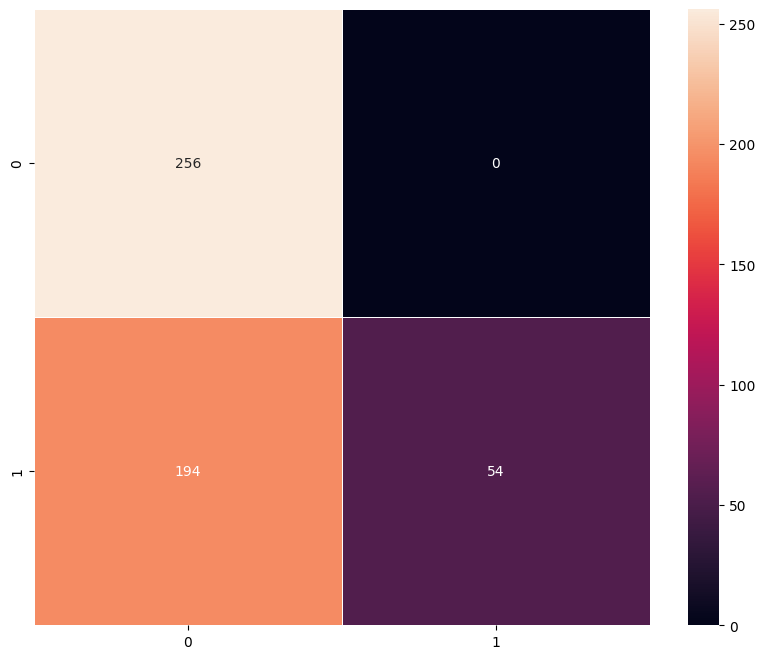

In [107]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [108]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.587302  0.587302   0.772304  0.497884


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


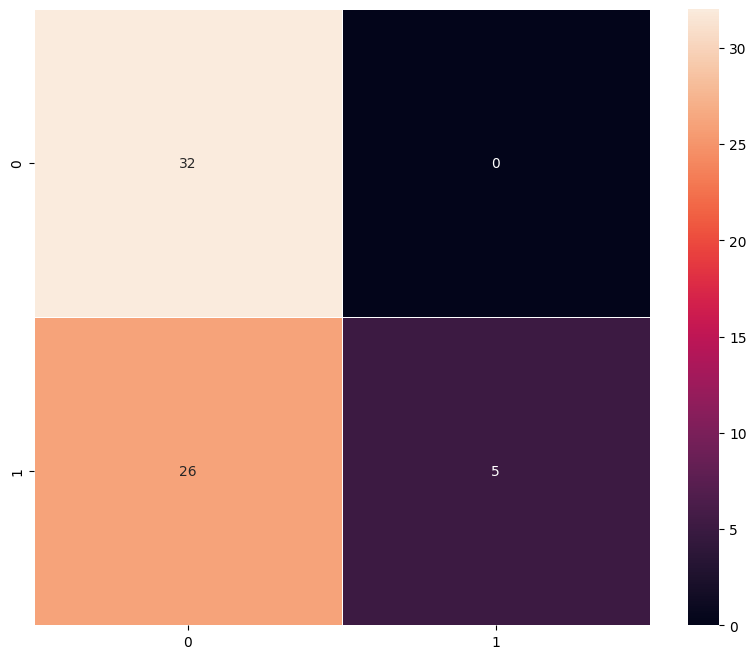

In [109]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

### Vizualizing the predictions

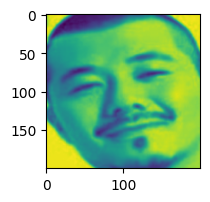

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
Predicted Label [[0.09598581]]
True Label Label    0
Name: 603, dtype: int64


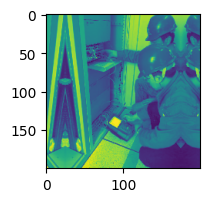

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Label [[0.23244137]]
True Label Label    1
Name: 59, dtype: int64


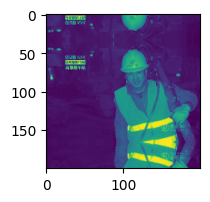

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted Label [[0.21038796]]
True Label Label    1
Name: 175, dtype: int64


In [110]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', model_1.predict((X_val_normalized[2].reshape(1,200,200,1))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[2])

plt.figure(figsize=(2,2))
plt.imshow(X_val[10])
plt.show()
print('Predicted Label', model_1.predict((X_val_normalized[10].reshape(1,200,200,1))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[10])

plt.figure(figsize=(2,2))
plt.imshow(X_val[23])
plt.show()
print('Predicted Label', model_1.predict((X_val_normalized[23].reshape(1,200,200,1))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[23])

### **Findings**

- Simple CNN model had 676,401 trainable parameters.
- Train and validation scores are close (≈61% vs ≈59%), which suggests the model is learning patterns that generalize, rather than memorizing.
- The model is cautious — when it predicts positive, it’s often correct (high precision), but it misses many true positives (lower recall).
- F1 around 0.5: This balance shows the model is better than random guessing but still far from robust performance.

## Model 2: (VGG-16 (Base))

In [111]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [112]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [113]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [114]:
model_2.compile(loss="binary_crossentropy", optimizer="adam", metrics = ['accuracy'])
model_2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [115]:
train_datagen_2 = ImageDataGenerator()

In [116]:
# Epochs
epochs = 20
# Batch size
batch_size = 32

history_model_2 = model_2.fit(train_datagen_2.flow(X_train_vgg_normalized,y_train_vgg,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_vgg_normalized.shape[0] // batch_size,
                    validation_data=(X_val_vgg_normalized,y_val_vgg),
                    verbose=1)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 457ms/step - accuracy: 0.9576 - loss: 0.1152 - val_accuracy: 1.0000 - val_loss: 0.0062
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 6.9768e-04 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 4.9615e-04 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 9.3327e-04 - val_accu

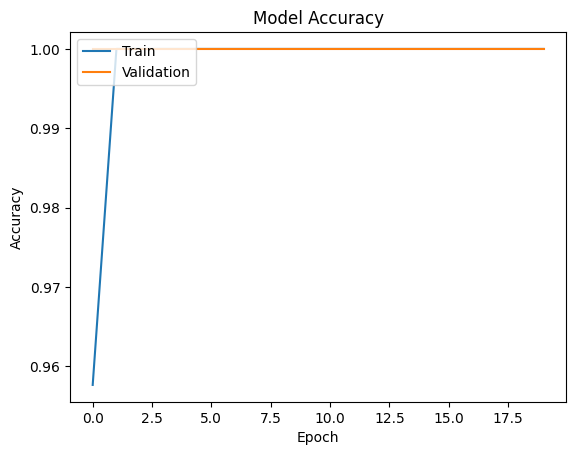

In [117]:
plt.plot(history_model_2.history['accuracy'])
plt.plot(history_model_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [118]:
model_2_train_perf = model_performance_classification(model_2, X_train_vgg_normalized,y_train_vgg)

print("Train performance metrics")
print(model_2_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step


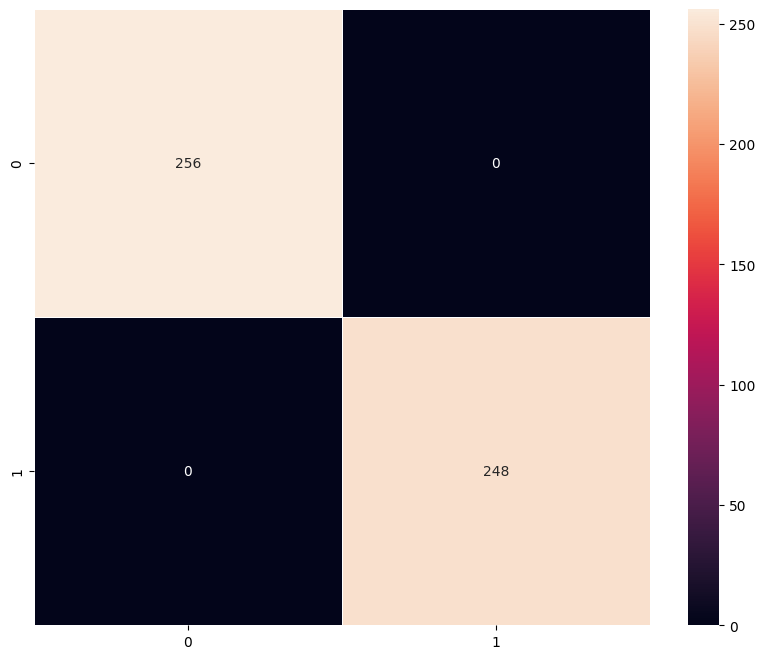

In [119]:
plot_confusion_matrix(model_2,X_train_vgg_normalized,y_train_vgg)

In [120]:
model_2_valid_perf = model_performance_classification(model_2, X_val_vgg_normalized,y_val_vgg)

print("Validation performance metrics")
print(model_2_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


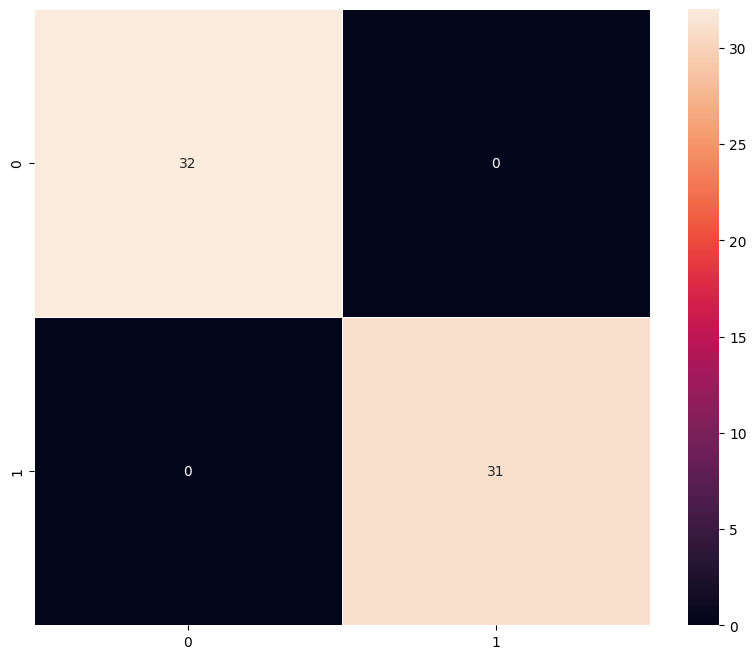

In [121]:
plot_confusion_matrix(model_2,X_val_vgg_normalized,y_val_vgg)

### Visualizing the prediction:

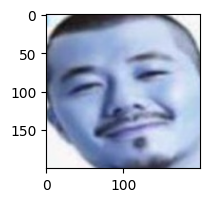

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
Predicted Label [[6.081345e-05]]
True Label Label    0
Name: 603, dtype: int64


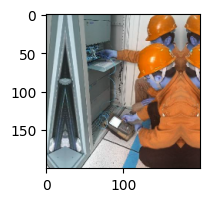

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Label [[0.99998164]]
True Label Label    1
Name: 59, dtype: int64


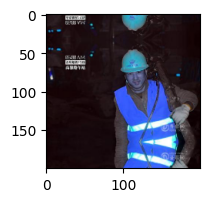

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Label [[0.9996863]]
True Label Label    1
Name: 175, dtype: int64


In [122]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[2])
plt.show()
print('Predicted Label', model_2.predict((X_val_vgg_normalized[2].reshape(1,200,200,3))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val_vgg.iloc[2])

plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[10])
plt.show()
print('Predicted Label', model_2.predict((X_val_vgg_normalized[10].reshape(1,200,200,3))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val_vgg.iloc[10])

plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[23])
plt.show()
print('Predicted Label', model_2.predict((X_val_vgg_normalized[23].reshape(1,200,200,3))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val_vgg.iloc[23])

### **Findings**

- Simple VGG-16(Base) model had 18,433 trainable parameters.
- Training accuracy/loss: Accuracy = 100%, loss ≈ 0.0005 by the end.
- Validation accuracy/loss: Accuracy = 100%, loss ≈ 0.001.
- Performance metrics: Accuracy, recall, precision, F1 = 1.0 for both train and validation.
- The model is achieving perfect scores it look likes the dataset is very small or the classes are trivially separable.

## Model 3: (VGG-16 (Base + FFNN))

In [123]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(128,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [124]:
model_3.compile(loss="binary_crossentropy", optimizer="adam", metrics = ['accuracy'])
model_3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,078,273 (65.15 MB)

 Trainable params: 2,363,585 (9.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [125]:
train_datagen_3 = ImageDataGenerator()

In [126]:
# Epochs
epochs = 20
# Batch size
batch_size = 32

history_model_3 = model_3.fit(train_datagen_3.flow(X_train_vgg_normalized,y_train_vgg,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_vgg_normalized.shape[0] // batch_size,
                    validation_data=(X_val_vgg_normalized,y_val_vgg),
                    verbose=1)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.9068 - loss: 0.1841 - val_accuracy: 1.0000 - val_loss: 5.0367e-04
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 4.8885e-04 - val_accuracy: 1.0000 - val_loss: 1.5856e-04
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.9958 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 1.6145e-05
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 7.0333e-05 - val_accuracy: 1.0000 - val_loss: 2.2024e-05
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 2.5056e-05
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 5.1537e-06 - val_accuracy: 1.0000 - val_loss: 2.3300e-05
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 1.0000 - loss: 2.6653e-04 - val_accuracy: 1.0000 - val_loss: 6.6831e-06
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy:

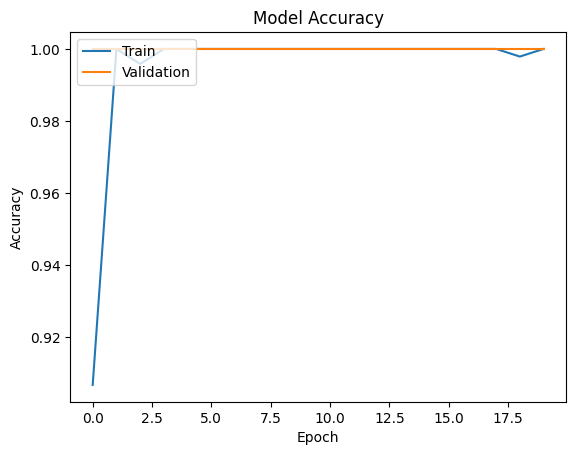

In [127]:
plt.plot(history_model_3.history['accuracy'])
plt.plot(history_model_3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [128]:
model_3_train_perf = model_performance_classification(model_3, X_train_vgg_normalized,y_train_vgg)

print("Train performance metrics")
print(model_3_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step


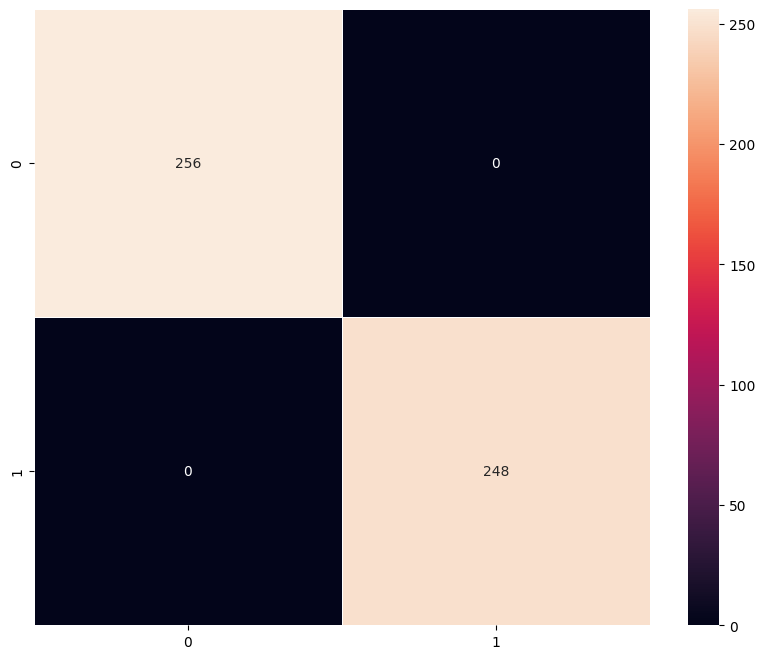

In [129]:
plot_confusion_matrix(model_3,X_train_vgg_normalized,y_train_vgg)

In [130]:
model_3_valid_perf = model_performance_classification(model_3, X_val_vgg_normalized,y_val_vgg)

print("Validation performance metrics")
print(model_3_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


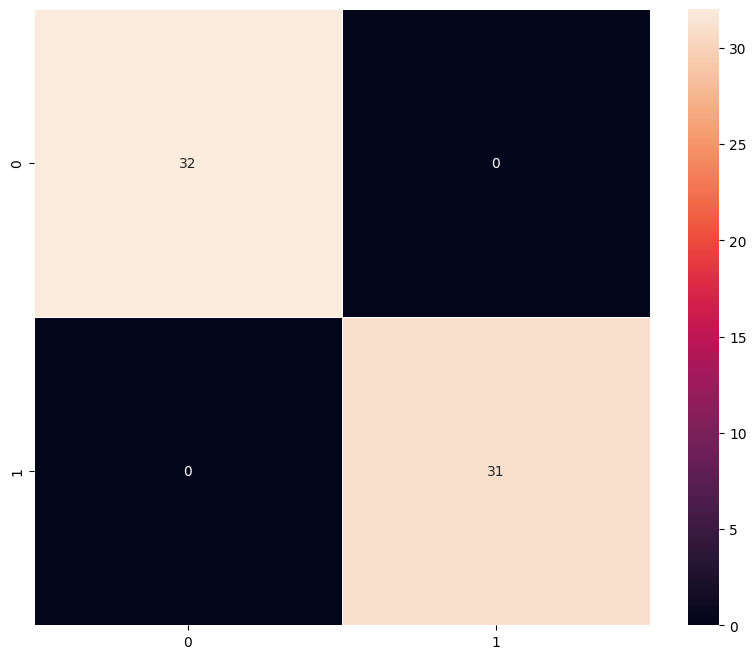

In [131]:
plot_confusion_matrix(model_3,X_val_vgg_normalized,y_val_vgg)

#### Visualizing the predictions

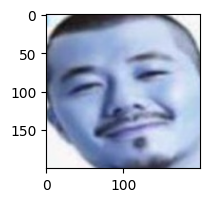

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step
Predicted Label [[3.5092196e-08]]
True Label Label    0
Name: 603, dtype: int64


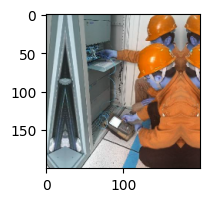

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Label [[1.]]
True Label Label    1
Name: 59, dtype: int64


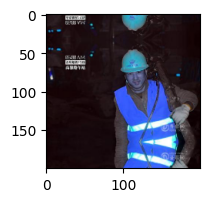

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Label [[1.]]
True Label Label    1
Name: 175, dtype: int64


In [132]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[2])
plt.show()
print('Predicted Label', model_3.predict((X_val_vgg_normalized[2].reshape(1,200,200,3))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[2])

plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[10])
plt.show()
print('Predicted Label', model_3.predict((X_val_vgg_normalized[10].reshape(1,200,200,3))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[10])

plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[23])
plt.show()
print('Predicted Label', model_3.predict((X_val_vgg_normalized[23].reshape(1,200,200,3))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[23])

### **Findings**

- Simple VGG-16(FFNN) model had 2,363,585 trainable parameters.
- Training accuracy/loss: Accuracy = 100%, loss ≈ 0.00007 by the end.
- Validation accuracy/loss: Accuracy = 100%, loss ≈ 0.00001.
- Performance metrics: Accuracy, recall, precision, F1 = 1.0 for both train and validation.
- As expected, The model is achieving perfect scores with feed forward neural network.

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [133]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(128,activation='relu'))
model_4.add(Dropout(rate=0.4))
model_4.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid'))

In [134]:
model_4.compile(loss="binary_crossentropy", optimizer="adam", metrics = ['accuracy'])
model_4.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,078,273 (65.15 MB)

 Trainable params: 2,363,585 (9.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [135]:
# Applying data augmentation
train_datagen_4 = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              )

In [136]:
# Epochs
epochs = 20
# Batch size
batch_size = 32

history_model_4 = model_4.fit(train_datagen_4.flow(X_train_vgg_normalized,y_train_vgg,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_vgg_normalized.shape[0] // batch_size,
                    validation_data=(X_val_vgg_normalized,y_val_vgg),
                    verbose=1)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 616ms/step - accuracy: 0.8369 - loss: 0.3425 - val_accuracy: 1.0000 - val_loss: 7.3645e-04
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9688 - loss: 0.0290 - val_accuracy: 1.0000 - val_loss: 2.8602e-04
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 369ms/step - accuracy: 0.9936 - loss: 0.0211 - val_accuracy: 1.0000 - val_loss: 9.0463e-06
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 1.0892e-05
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 385ms/step - accuracy: 0.9917 - loss: 0.0264 - val_accuracy: 1.0000 - val_loss: 1.4466e-04
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9583 - loss: 0.1051 - val_accuracy: 1.0000 - val_loss: 6.0907e-05
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 407ms/step - accuracy: 0.9958 - loss: 0.0091 - val_accuracy: 1.0000 - val_loss: 2.2622e-06
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9688 - loss: 

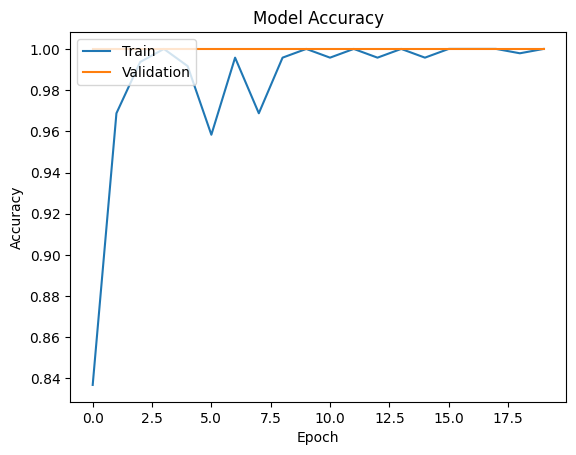

In [137]:
plt.plot(history_model_4.history['accuracy'])
plt.plot(history_model_4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [138]:
model_4_train_perf = model_performance_classification(model_4, X_train_vgg_normalized,y_train_vgg)

print("Train performance metrics")
print(model_4_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step


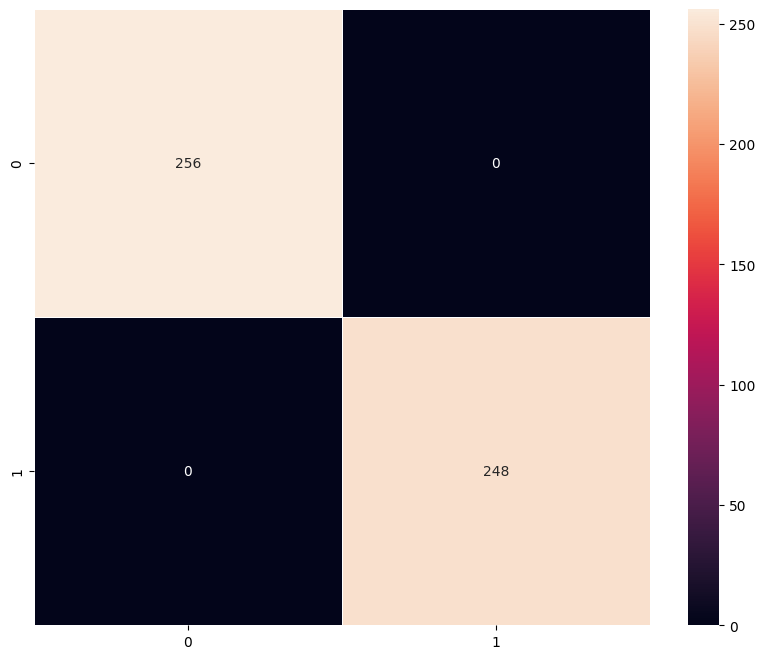

In [139]:
plot_confusion_matrix(model_4,X_train_vgg_normalized,y_train_vgg)

In [140]:
model_4_valid_perf = model_performance_classification(model_4, X_val_vgg_normalized,y_val_vgg)

print("Validation performance metrics")
print(model_4_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


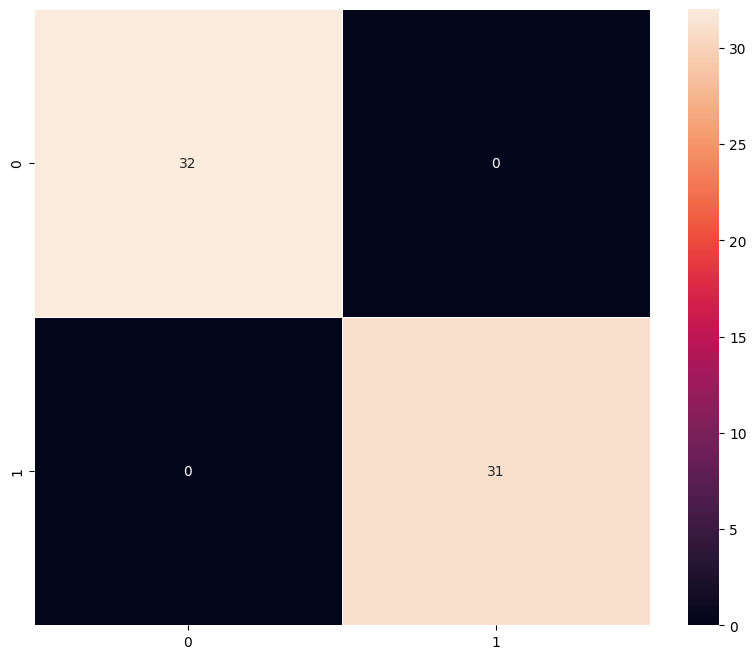

In [141]:
plot_confusion_matrix(model_4,X_val_vgg_normalized,y_val_vgg)

#### Visualizing the predictions

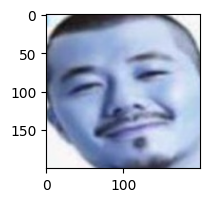

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
Predicted Label [[4.5950506e-09]]
True Label Label    0
Name: 603, dtype: int64


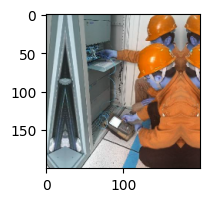

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Label [[1.]]
True Label Label    1
Name: 59, dtype: int64


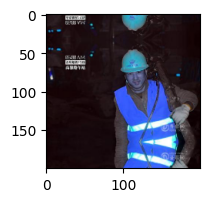

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Label [[1.]]
True Label Label    1
Name: 175, dtype: int64


In [142]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[2])
plt.show()
print('Predicted Label', model_4.predict((X_val_vgg_normalized[2].reshape(1,200,200,3))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[2])

plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[10])
plt.show()
print('Predicted Label', model_4.predict((X_val_vgg_normalized[10].reshape(1,200,200,3))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[10])

plt.figure(figsize=(2,2))
plt.imshow(X_val_vgg[23])
plt.show()
print('Predicted Label', model_4.predict((X_val_vgg_normalized[23].reshape(1,200,200,3))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_val.iloc[23])

### **Findings**

- Simple VGG-16(FFNN+ Data Augmentation) model had 2,363,585 trainable parameters.
- Training accuracy/loss: Accuracy = 100%, loss ≈ 0.0001 by the end.
- Validation accuracy/loss: Accuracy = 100%, loss ≈ 0.00001.
- Performance metrics: Accuracy, recall, precision, F1 = 1.0 for both train and validation.
- The model is achieving perfect scores again even with data augmentation.

# **Model Performance Comparison and Final Model Selection**

In [143]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple CNN", "VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [144]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T,

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple CNN", "VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [145]:
models_train_comp_df

,Simple CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.615079,1.0,1.0,1.0
Recall,0.615079,1.0,1.0,1.0
Precision,0.781023,1.0,1.0,1.0
F1 Score,0.544332,1.0,1.0,1.0


In [146]:
models_valid_comp_df

,Simple CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.587302,1.0,1.0,1.0
Recall,0.587302,1.0,1.0,1.0
Precision,0.772304,1.0,1.0,1.0
F1 Score,0.497884,1.0,1.0,1.0


In [147]:
models_train_comp_df - models_valid_comp_df

,Simple CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.027778,0.0,0.0,0.0
Recall,0.027778,0.0,0.0,0.0
Precision,0.008719,0.0,0.0,0.0
F1 Score,0.046448,0.0,0.0,0.0


- As we can see, The accuracy, precision, recall and f1 score, all are 100% for all the models except Simple CNN model.
- So, we will choose the best model out of below three models:
  - Simple VGG-16(Base) model had 18,433 trainable parameters.
  - Simple VGG-16(FFNN) model had 2,363,585 trainable parameters.
  - Simple VGG-16(FFNN+ Data Augmentation) model had 2,363,585 trainable parameters.
-  Based on the trainiable paramters, Simple VGG-16(Base) has lower Trainiable paramters, so, We will choose this model as our final model.


## Test Performance

In [148]:
model_2_test_perf = model_performance_classification(model_2, X_test_vgg_normalized,y_test_vgg)
print("Test performance metrics")
print(model_2_test_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Test performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


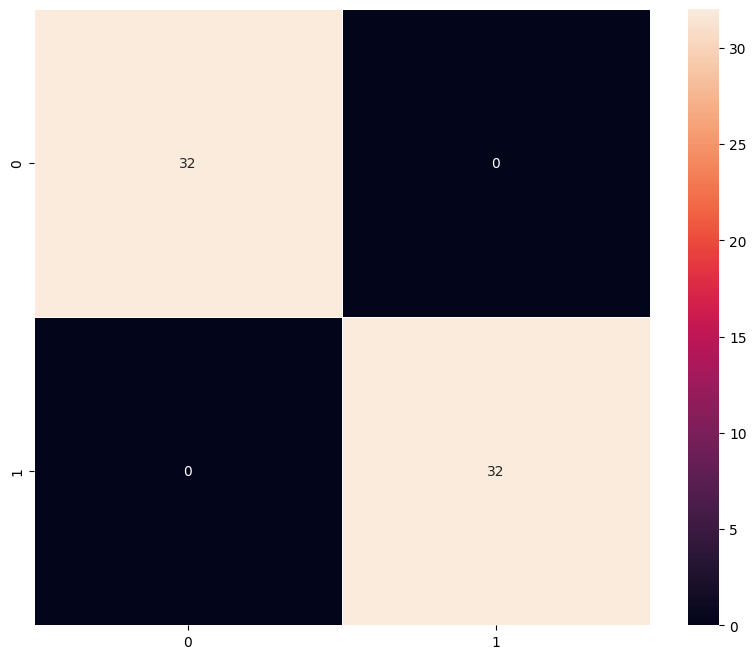

In [149]:
plot_confusion_matrix(model_2,X_test_vgg_normalized,y_test_vgg)

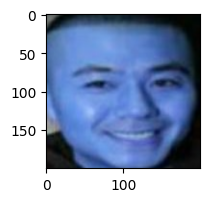

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Label [[1.7161154e-05]]
True Label Label    0
Name: 320, dtype: int64


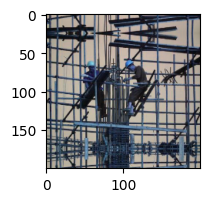

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Label [[0.9999949]]
True Label Label    1
Name: 141, dtype: int64


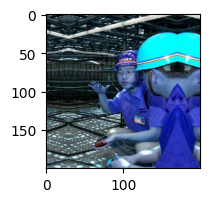

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Label [[0.99991894]]
True Label Label    1
Name: 222, dtype: int64


In [150]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_test_vgg[2])
plt.show()
print('Predicted Label', model_2.predict((X_test_vgg_normalized[2].reshape(1,200,200,3))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_test_vgg.iloc[2])

plt.figure(figsize=(2,2))
plt.imshow(X_test_vgg[10])
plt.show()
print('Predicted Label', model_2.predict((X_test_vgg_normalized[10].reshape(1,200,200,3))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_test_vgg.iloc[10])

plt.figure(figsize=(2,2))
plt.imshow(X_test_vgg[23])
plt.show()
print('Predicted Label', model_2.predict((X_test_vgg_normalized[23].reshape(1,200,200,3))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', y_test_vgg.iloc[23])

# **Actionable Insights & Recommendations**

- The simple CNN model having 676,401 trainable parameters, trained with 15 epochs, it attain the accuracy of ~58%. It looks like the model is over‑predicting one class incorrectly.
- The VGG-16 (Base) model with 18,433 trainable parameters performed excellent on the training data as well as on validation data, achieving a train accuracy and  validation F1-score of 100%. This indicates that the pre-trained features were quite valuable for this dataset.
- This also suggests that the dataset is very small and classes are visually distinct (e.g., helmets vs. no helmets with clear backgrounds), VGG16 can genuinely memorize and generalize perfectly.
- As expected, Adding a feed-forward neural network on top of the VGG-16 model does not degrade performance. It is producing the same output as base model. Bit it has 2,363,585 trainable parameters.
- Simple VGG-16(FFNN+ Data Augmentation) model has also produces the same output as the other models.
- Before deploying the model on production, we have to test it with more images.
so that we can make sure that it will predict correctly there.
- right now, we have used the original image size for training and validation with VGG 16 model, But we can re size it to the 224*224 whic is the size of the images on which VGG 16 has trained.


<font size=5 color='blue'>Power Ahead!</font>
___